In [1]:
import numpy as np
import pandas as pd
from numpy.core.defchararray import endswith

from utils import *

In [2]:
df_combined = pd.read_csv("Experiment/3_hTERT_HME1_mutants_comparison/Data/Processed/combined_modified_peptide_renamed_2.tsv", sep="\t")
df_combined

,protein_Id,protein_name,description,Peptide_Sequence,Modified_Sequence,site_start,site_end,Peptide_Length,Charges,Assigned_Modifications,...,BRAFS151A_localization_EGF_10_r2,BRAFS151A_localization_EGF_25_r1,BRAFS151A_localization_EGF_25_r2,GAB1Y259A_localization_EGF_starve_r1,GAB1Y259A_localization_EGF_2_r1,GAB1Y259A_localization_EGF_2_r2,GAB1Y259A_localization_EGF_10_r1,GAB1Y259A_localization_EGF_10_r2,GAB1Y259A_localization_EGF_25_r1,GAB1Y259A_localization_EGF_25_r2
0,P0CG40,SP9,Transcription factor Sp9,AAAAAAAAAAAAAAAASAGGKEAASGPNDS,AAAAAAAAAAAAAAAASAGGKEAAS[79.9663]GPNDS[79.9663],455,484,30,2,"25S(79.9663),30S(79.9663)",...,STY:79.9663@AAAAAAAAAAAAAAAAS(0.3985)AGGKEAAS(...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,P0CG40,SP9,Transcription factor Sp9,AAAAAAAAAAAAAAAASAGGK,AAAAAAAAAAAAAAAAS[79.9663]AGGK,455,475,21,2,17S(79.9663),...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,P0CG40,SP9,Transcription factor Sp9,AAAAAAAAAAAAAAAASAGGKEAASGPNDS,AAAAAAAAAAAAAAAAS[79.9663]AGGKEAAS[79.9663]GPNDS,455,484,30,2,"17S(79.9663),25S(79.9663)",...,STY:79.9663@AAAAAAAAAAAAAAAAS(0.6939)AGGKEAAS(...,NaN,NaN,STY:79.9663@AAAAAAAAAAAAAAAAS(0.6667)AGGKEAAS(...,STY:79.9663@AAAAAAAAAAAAAAAAS(0.6667)AGGKEAAS(...,NaN,NaN,NaN,STY:79.9663@AAAAAAAAAAAAAAAAS(0.7806)AGGKEAAS(...,STY:79.9663@AAAAAAAAAAAAAAAAS(0.6667)AGGKEAAS(...
3,Q8WXD9,CASKIN1,Caskin-1,AAAAAAAAAAAPPAPPEGASPGDSARQK,AAAAAAAAAAAPPAPPEGASPGDSARQK,1345,1372,28,2,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Q8WXD9,CASKIN1,Caskin-1,AAAAAAAAAAAPPAPPEGASPGDSAR,AAAAAAAAAAAPPAPPEGAS[79.9663]PGDS[79.9663]AR,1345,1370,26,2,"20S(79.9663),24S(79.9663)",...,STY:79.9663@AAAAAAAAAAAPPAPPEGAS(1.0000)PGDS(1...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,STY:79.9663@AAAAAAAAAAAPPAPPEGAS(1.0000)PGDS(1...,STY:79.9663@AAAAAAAAAAAPPAPPEGAS(1.0000)PGDS(1...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175084,P55735,SEC13,Protein SEC13 homolog,VSVINTVDTSHEDMIHDAQMDYYGTR,n[42.0106]VSVINTVDTSHEDM[15.9949]IHDAQMDYYGTR,2,27,26,3,"N-term(42.0106),14M(15.9949)",...,M:15.9949@VSVINTVDTSHEDM(0.9426)IHDAQM(0.0574)...,M:15.9949@VSVINTVDTSHEDM(0.8966)IHDAQM(0.1034)...,NaN,M:15.9949@VSVINTVDTSHEDM(0.9445)IHDAQM(0.0555)...,M:15.9949@VSVINTVDTSHEDM(0.9210)IHDAQM(0.0790)...,M:15.9949@VSVINTVDTSHEDM(0.9424)IHDAQM(0.0576)...,M:15.9949@VSVINTVDTSHEDM(0.9402)IHDAQM(0.0598)...,M:15.9949@VSVINTVDTSHEDM(0.9424)IHDAQM(0.0576)...,M:15.9949@VSVINTVDTSHEDM(0.9418)IHDAQM(0.0582)...,M:15.9949@VSVINTVDTSHEDM(0.9426)IHDAQM(0.0574)...
175085,P55735,SEC13,Protein SEC13 homolog,VSVINTVDTSHEDMIHDAQMDYYGTR,n[42.0106]VSVINTVDTSHEDM[15.9949]IHDAQM[15.994...,2,27,26,3,"N-term(42.0106),14M(15.9949),20M(15.9949)",...,NaN,NaN,NaN,M:15.9949@VSVINTVDTSHEDM(1.0000)IHDAQM(1.0000)...,NaN,M:15.9949@VSVINTVDTSHEDM(1.0000)IHDAQM(1.0000)...,M:15.9949@VSVINTVDTSHEDM(1.0000)IHDAQM(1.0000)...,M:15.9949@VSVINTVDTSHEDM(1.0000)IHDAQM(1.0000)...,M:15.9949@VSVINTVDTSHEDM(1.0000)IHDAQM(1.0000)...,NaN
175086,rev_Q17R98,rev_ZNF827,Zinc finger protein 827,WQGSNLGGTPVTHCK,n[42.0106]WQGSNLGGTPVTHC[57.0215]K,2,16,15,2,"N-term(42.0106),14C(57.0215)",...,NaN,n:42.0106@n(1.0000)WQGSNLGGTPVTHCK;,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
175087,Q9NRJ4,TULP4,Tubby-related protein 4,YAAVEHGPVLCSDSNILCLSWK,n[42.0106]YAAVEHGPVLC[57.0215]S[79.9663]DSNILC...,2,23,22,2,"N-term(42.0106),11C(57.0215),12S(79.9663),18C(...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Re define columns

In [3]:
# Re define some columns for how many sites are localized, which type of modification was localized and how many
# Number of modifications localized
df_combined["n_localized"] = df_combined["Assigned_Modifications"].str.split(",").str.len().fillna(0).astype(int)

# Number of SYT modification localized
df_combined["STY_localized"] = (df_combined["Assigned_Modifications"]
                                .str.split(",")
                                .apply(lambda x: sum(any(c in item for c in "TYS") for item in x) if isinstance(x, list) else 0)
                                )

# Number of other modifications localized
df_combined["other_localized"] = (df_combined["Assigned_Modifications"]
                                .str.split(",")
                                .apply(lambda x: sum(not any(c in item for c in "TYS") for item in x) if isinstance(x, list) else 0)
                                )

# True or False if all modifications where localized (both STY and other)
df_combined["all_localized"] = df_combined["STY_localized"].astype(int) + df_combined["other_localized"].astype(int) == df_combined["Charges"].str.split(",").str[0].astype(int)

# Re-annotation for the modifications localization
df_combined["Assigned_Modifications_clean"] = df_combined["Assigned_Modifications"].str.replace(r"\s*\([^)]*\)", "", regex=True)
df_combined["Assigned_Modifications_clean"] = df_combined["Assigned_Modifications_clean"].str.replace(r"\b(\d+)([A-Za-z])\b", r"\2\1", regex=True)
df_combined["Assigned_Modifications_clean"] = df_combined["Assigned_Modifications_clean"].str.replace(r",", "", regex=True)

# Offset the residue numbers in Assigned_Modifications_clean by site_start
# e.g. site_start=346, "S2T15Y18" -> "S348T361Y364"
def offset_modification_positions(row):
    mod_str = row["Assigned_Modifications_clean"]
    site_start = row["site_start"]

    if pd.isna(mod_str) or pd.isna(site_start) or mod_str == "":
        return mod_str

    # Find all (amino_acid_letter, position_number) pairs and offset the number
    offsetted = re.sub(
        r"([A-Za-z])(\d+)",
        lambda m: f"{m.group(1)}{int(m.group(2)) + int(site_start) - 1}",
        mod_str
    )
    return offsetted

df_combined["Assigned_Modifications_clean"] = df_combined.apply(offset_modification_positions, axis=1)

# Create the site column with all the information
df_combined["site"] = (df_combined["protein_Id"].astype(str) + "_"
                       + df_combined["site_start"].astype(str) + "_"
                       + df_combined["site_end"].astype(str) + "_"
                       + df_combined["n_localized"].astype(str) + "_"
                       + df_combined["STY_localized"].astype(str) + "_"
                       + df_combined["all_localized"].astype(str) + "_"
                       + df_combined["Assigned_Modifications_clean"])

df_combined

,protein_Id,protein_name,description,Peptide_Sequence,Modified_Sequence,site_start,site_end,Peptide_Length,Charges,Assigned_Modifications,...,GAB1Y259A_localization_EGF_10_r1,GAB1Y259A_localization_EGF_10_r2,GAB1Y259A_localization_EGF_25_r1,GAB1Y259A_localization_EGF_25_r2,n_localized,STY_localized,other_localized,all_localized,Assigned_Modifications_clean,site
0,P0CG40,SP9,Transcription factor Sp9,AAAAAAAAAAAAAAAASAGGKEAASGPNDS,AAAAAAAAAAAAAAAASAGGKEAAS[79.9663]GPNDS[79.9663],455,484,30,2,"25S(79.9663),30S(79.9663)",...,NaN,NaN,NaN,NaN,2,2,0,True,S479S484,P0CG40_455_484_2_2_True_S479S484
1,P0CG40,SP9,Transcription factor Sp9,AAAAAAAAAAAAAAAASAGGK,AAAAAAAAAAAAAAAAS[79.9663]AGGK,455,475,21,2,17S(79.9663),...,NaN,NaN,NaN,NaN,1,1,0,False,S471,P0CG40_455_475_1_1_False_S471
2,P0CG40,SP9,Transcription factor Sp9,AAAAAAAAAAAAAAAASAGGKEAASGPNDS,AAAAAAAAAAAAAAAAS[79.9663]AGGKEAAS[79.9663]GPNDS,455,484,30,2,"17S(79.9663),25S(79.9663)",...,NaN,NaN,STY:79.9663@AAAAAAAAAAAAAAAAS(0.7806)AGGKEAAS(...,STY:79.9663@AAAAAAAAAAAAAAAAS(0.6667)AGGKEAAS(...,2,2,0,True,S471S479,P0CG40_455_484_2_2_True_S471S479
3,Q8WXD9,CASKIN1,Caskin-1,AAAAAAAAAAAPPAPPEGASPGDSARQK,AAAAAAAAAAAPPAPPEGASPGDSARQK,1345,1372,28,2,NaN,...,NaN,NaN,NaN,NaN,0,0,0,False,NaN,NaN
4,Q8WXD9,CASKIN1,Caskin-1,AAAAAAAAAAAPPAPPEGASPGDSAR,AAAAAAAAAAAPPAPPEGAS[79.9663]PGDS[79.9663]AR,1345,1370,26,2,"20S(79.9663),24S(79.9663)",...,NaN,NaN,STY:79.9663@AAAAAAAAAAAPPAPPEGAS(1.0000)PGDS(1...,STY:79.9663@AAAAAAAAAAAPPAPPEGAS(1.0000)PGDS(1...,2,2,0,True,S1364S1368,Q8WXD9_1345_1370_2_2_True_S1364S1368
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175084,P55735,SEC13,Protein SEC13 homolog,VSVINTVDTSHEDMIHDAQMDYYGTR,n[42.0106]VSVINTVDTSHEDM[15.9949]IHDAQMDYYGTR,2,27,26,3,"N-term(42.0106),14M(15.9949)",...,M:15.9949@VSVINTVDTSHEDM(0.9402)IHDAQM(0.0598)...,M:15.9949@VSVINTVDTSHEDM(0.9424)IHDAQM(0.0576)...,M:15.9949@VSVINTVDTSHEDM(0.9418)IHDAQM(0.0582)...,M:15.9949@VSVINTVDTSHEDM(0.9426)IHDAQM(0.0574)...,2,0,2,False,N-termM15,P55735_2_27_2_0_False_N-termM15
175085,P55735,SEC13,Protein SEC13 homolog,VSVINTVDTSHEDMIHDAQMDYYGTR,n[42.0106]VSVINTVDTSHEDM[15.9949]IHDAQM[15.994...,2,27,26,3,"N-term(42.0106),14M(15.9949),20M(15.9949)",...,M:15.9949@VSVINTVDTSHEDM(1.0000)IHDAQM(1.0000)...,M:15.9949@VSVINTVDTSHEDM(1.0000)IHDAQM(1.0000)...,M:15.9949@VSVINTVDTSHEDM(1.0000)IHDAQM(1.0000)...,NaN,3,0,3,True,N-termM15M21,P55735_2_27_3_0_True_N-termM15M21
175086,rev_Q17R98,rev_ZNF827,Zinc finger protein 827,WQGSNLGGTPVTHCK,n[42.0106]WQGSNLGGTPVTHC[57.0215]K,2,16,15,2,"N-term(42.0106),14C(57.0215)",...,NaN,NaN,NaN,NaN,2,0,2,True,N-termC15,rev_Q17R98_2_16_2_0_True_N-termC15
175087,Q9NRJ4,TULP4,Tubby-related protein 4,YAAVEHGPVLCSDSNILCLSWK,n[42.0106]YAAVEHGPVLC[57.0215]S[79.9663]DSNILC...,2,23,22,2,"N-term(42.0106),11C(57.0215),12S(79.9663),18C(...",...,NaN,NaN,NaN,NaN,5,2,3,False,N-termC12S13C19S21,Q9NRJ4_2_23_5_2_False_N-termC12S13C19S21


## create new columns list

In [4]:
# Check wich are the names of the columns with raw calues
raw_columns = [element for element in df_combined.columns if 'raw' in element]
print(raw_columns)

# Create the colums for the log2 trasformation of the data
log2_abs_coulmns = [element.replace("raw:abs_", "log2:abs_") for element in raw_columns]
print(log2_abs_coulmns)

# Create the colums for the log2 means
log2_mean_coulmns = [element.replace("log2:abs", "log2:mean") for element in log2_abs_coulmns ]
log2_mean_coulmns = [re.sub(r"_r[1-9]", "", element) for element in log2_mean_coulmns]
log2_mean_coulmns = list(dict.fromkeys(log2_mean_coulmns))
print(log2_mean_coulmns)

# Create the colums for the log2_FC calculations
log2_FC_columns = [element.replace("log2:mean", "log2:FC") for element in log2_mean_coulmns]
print(log2_FC_columns)

['WT_raw:abs_EGF_starve_r1', 'WT_raw:abs_EGF_2_r1', 'WT_raw:abs_EGF_2_r2', 'WT_raw:abs_EGF_10_r1', 'WT_raw:abs_EGF_10_r2', 'WT_raw:abs_EGF_25_r1', 'WT_raw:abs_EGF_25_r2', 'BRAFS151A_raw:abs_EGF_starve_r1', 'BRAFS151A_raw:abs_EGF_2_r1', 'BRAFS151A_raw:abs_EGF_2_r2', 'BRAFS151A_raw:abs_EGF_10_r1', 'BRAFS151A_raw:abs_EGF_10_r2', 'BRAFS151A_raw:abs_EGF_25_r1', 'BRAFS151A_raw:abs_EGF_25_r2', 'GAB1Y259A_raw:abs_EGF_starve_r1', 'GAB1Y259A_raw:abs_EGF_2_r1', 'GAB1Y259A_raw:abs_EGF_2_r2', 'GAB1Y259A_raw:abs_EGF_10_r1', 'GAB1Y259A_raw:abs_EGF_10_r2', 'GAB1Y259A_raw:abs_EGF_25_r1', 'GAB1Y259A_raw:abs_EGF_25_r2']
['WT_log2:abs_EGF_starve_r1', 'WT_log2:abs_EGF_2_r1', 'WT_log2:abs_EGF_2_r2', 'WT_log2:abs_EGF_10_r1', 'WT_log2:abs_EGF_10_r2', 'WT_log2:abs_EGF_25_r1', 'WT_log2:abs_EGF_25_r2', 'BRAFS151A_log2:abs_EGF_starve_r1', 'BRAFS151A_log2:abs_EGF_2_r1', 'BRAFS151A_log2:abs_EGF_2_r2', 'BRAFS151A_log2:abs_EGF_10_r1', 'BRAFS151A_log2:abs_EGF_10_r2', 'BRAFS151A_log2:abs_EGF_25_r1', 'BRAFS151A_log2:abs

# Data clean up
## Remove rows without PTM and site not detected in the starvation

In [5]:
# Remove rows without PTM
df_combined = df_combined[df_combined.Assigned_Modifications_clean.notna()]
df_combined

# Drop rows where site is not detected in the starvation control
df_combined = df_combined[df_combined["WT_raw:abs_EGF_starve_r1"] != 0]
df_combined = df_combined[df_combined["BRAFS151A_raw:abs_EGF_starve_r1"] != 0]
df_combined = df_combined[df_combined["GAB1Y259A_raw:abs_EGF_starve_r1"] != 0]

df_combined

,protein_Id,protein_name,description,Peptide_Sequence,Modified_Sequence,site_start,site_end,Peptide_Length,Charges,Assigned_Modifications,...,GAB1Y259A_localization_EGF_10_r1,GAB1Y259A_localization_EGF_10_r2,GAB1Y259A_localization_EGF_25_r1,GAB1Y259A_localization_EGF_25_r2,n_localized,STY_localized,other_localized,all_localized,Assigned_Modifications_clean,site
17,Q9NQS7,INCENP,Inner centromere protein,AAAAAAAATMALAAPSSPTPESPTMLTK,AAAAAAAATMALAAPS[79.9663]SPTPES[79.9663]PTMLTK,127,154,28,"2,3","16S(79.9663),22S(79.9663)",...,STY:79.9663@AAAAAAAAT(0.0281)MALAAPS(0.5714)S(...,STY:79.9663@AAAAAAAAT(0.0236)MALAAPS(0.5303)S(...,STY:79.9663@AAAAAAAAT(0.0208)MALAAPS(0.5692)S(...,STY:79.9663@AAAAAAAAT(0.0295)MALAAPS(0.8855)S(...,2,2,0,True,S142S148,Q9NQS7_127_154_2_2_True_S142S148
38,Q6SPF0,SAMD1,Sterile alpha motif domain-containing protein 1,AAAAAATAPPSPGPAQPGPR,AAAAAATAPPS[79.9663]PGPAQPGPR,151,170,20,2,11S(79.9663),...,STY:79.9663@AAAAAAT(0.0969)APPS(0.9031)PGPAQPGPR;,STY:79.9663@AAAAAAT(0.0889)APPS(0.9111)PGPAQPGPR;,STY:79.9663@AAAAAAT(0.0607)APPS(0.9393)PGPAQPGPR;,STY:79.9663@AAAAAAT(0.0569)APPS(0.9431)PGPAQPGPR;,1,1,0,False,S161,Q6SPF0_151_170_1_1_False_S161
43,P19338,NCL,Nucleolin,AAAAAPASEDEDDEDDEDDEDDDDDEEDDSEEEAMETTPAK,AAAAAPASEDEDDEDDEDDEDDDDDEEDDS[79.9663]EEEAMET...,177,217,41,3,30S(79.9663),...,STY:79.9663@AAAAAPAS(0.0183)EDEDDEDDEDDEDDDDDE...,STY:79.9663@AAAAAPAS(0.0184)EDEDDEDDEDDEDDDDDE...,STY:79.9663@AAAAAPAS(0.0182)EDEDDEDDEDDEDDDDDE...,STY:79.9663@AAAAAPAS(0.0182)EDEDDEDDEDDEDDDDDE...,1,1,0,False,S206,P19338_177_217_1_1_False_S206
44,P19338,NCL,Nucleolin,AAAAAPASEDEDDEDDEDDEDDDDDEEDDSEEEAMETTPAK,AAAAAPASEDEDDEDDEDDEDDDDDEEDDS[79.9663]EEEAM[1...,177,217,41,3,"30S(79.9663),35M(15.9949)",...,STY:79.9663@AAAAAPAS(0.0188)EDEDDEDDEDDEDDDDDE...,STY:79.9663@AAAAAPAS(0.0186)EDEDDEDDEDDEDDDDDE...,STY:79.9663@AAAAAPAS(0.0193)EDEDDEDDEDDEDDDDDE...,STY:79.9663@AAAAAPAS(0.0196)EDEDDEDDEDDEDDDDDE...,2,1,1,False,S206M211,P19338_177_217_2_1_False_S206M211
45,P19338,NCL,Nucleolin,AAAAAPASEDEDDEDDEDDEDDDDDEEDDSEEEAMETTPAK,AAAAAPAS[79.9663]EDEDDEDDEDDEDDDDDEEDDSEEEAMET...,177,217,41,3,8S(79.9663),...,STY:79.9663@AAAAAPAS(0.9430)EDEDDEDDEDDEDDDDDE...,STY:79.9663@AAAAAPAS(0.9450)EDEDDEDDEDDEDDDDDE...,STY:79.9663@AAAAAPAS(0.9440)EDEDDEDDEDDEDDDDDE...,STY:79.9663@AAAAAPAS(0.9438)EDEDDEDDEDDEDDDDDE...,1,1,0,False,S184,P19338_177_217_1_1_False_S184
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175069,P38159,RBMX,"RNA-binding motif protein, X chromosome",VEADRPGK,n[42.0106]VEADRPGK,2,9,8,2,N-term(42.0106),...,n:42.0106@n(1.0000)VEADRPGK;,n:42.0106@n(1.0000)VEADRPGK;,n:42.0106@n(1.0000)VEADRPGK;,n:42.0106@n(1.0000)VEADRPGK;,1,0,1,False,N-term,P38159_2_9_1_0_False_N-term
175071,Q9UBE0,SAE1,SUMO-activating enzyme subunit 1,VEKEEAGGGISEEEAAQYDR,n[42.0106]VEKEEAGGGISEEEAAQYDR,2,21,20,2,N-term(42.0106),...,n:42.0106@n(1.0000)VEKEEAGGGISEEEAAQYDR;,n:42.0106@n(1.0000)VEKEEAGGGISEEEAAQYDR;,n:42.0106@n(1.0000)VEKEEAGGGISEEEAAQYDR;,n:42.0106@n(1.0000)VEKEEAGGGISEEEAAQYDR;,1,0,1,False,N-term,Q9UBE0_2_21_1_0_False_N-term
175082,P55735,SEC13,Protein SEC13 homolog,VSVINTVDTSHEDMIHDAQMDYYGTR,n[42.0106]VSVINTVDTSHEDMIHDAQMDYYGTR,2,27,26,"2,3",N-term(42.0106),...,n:42.0106@n(1.0000)VSVINTVDTSHEDMIHDAQMDYYGTR;,n:42.0106@n(1.0000)VSVINTVDTSHEDMIHDAQMDYYGTR;,n:42.0106@n(1.0000)VSVINTVDTSHEDMIHDAQMDYYGTR;,n:42.0106@n(1.0000)VSVINTVDTSHEDMIHDAQMDYYGTR;,1,0,1,False,N-term,P55735_2_27_1_0_False_N-term
175083,P55735,SEC13,Protein SEC13 homolog,VSVINTVDTSHEDMIHDAQMDYYGTR,n[42.0106]VSVINTVDTSHEDMIHDAQM[15.9949]DYYGTR,2,27,26,3,"N-term(42.0106),20M(15.9949)",...,M:15.9949@VSVINTVDTSHEDM(0.0599)IHDAQM(0.9401)...,M:15.9949@VSVINTVDTSHEDM(0.0945)IHDAQM(0.9055)...,M:15.9949@VSVINTVDTSHEDM(0.2488)IHDAQM(0.7512)...,M:15.9949@VSVINTVDTSHEDM(0.0638)IHDAQM(0.9362)...,2,0,2,False,N-termM21,P55735_2_27_2_0_False_N-termM21


## remove sites when site is not detected for any of the replicates of a time point

In [44]:
replicates = [element for element in raw_columns if "starve" not in element]
replicates

replicates = list(set([element.replace("_r1", "").replace("_r2", "") for element in replicates]))

suffixes = ["_r1", "_r2"]

# Drop rows if the phosphosite was not detected in the 2 replicates for any time point and any condition
for condition in replicates:
    mask = (
        (df_combined[f"{condition}{suffixes[0]}"] == 0) &
        (df_combined[f"{condition}{suffixes[1]}"] == 0)
    )
    df_combined = df_combined.drop(df_combined[mask].index)

df_combined

,protein_Id,protein_name,description,Peptide_Sequence,Modified_Sequence,site_start,site_end,Peptide_Length,Charges,Assigned_Modifications,...,GAB1Y259A_localization_EGF_10_r1,GAB1Y259A_localization_EGF_10_r2,GAB1Y259A_localization_EGF_25_r1,GAB1Y259A_localization_EGF_25_r2,n_localized,STY_localized,other_localized,all_localized,Assigned_Modifications_clean,site
17,Q9NQS7,INCENP,Inner centromere protein,AAAAAAAATMALAAPSSPTPESPTMLTK,AAAAAAAATMALAAPS[79.9663]SPTPES[79.9663]PTMLTK,127,154,28,"2,3","16S(79.9663),22S(79.9663)",...,STY:79.9663@AAAAAAAAT(0.0281)MALAAPS(0.5714)S(...,STY:79.9663@AAAAAAAAT(0.0236)MALAAPS(0.5303)S(...,STY:79.9663@AAAAAAAAT(0.0208)MALAAPS(0.5692)S(...,STY:79.9663@AAAAAAAAT(0.0295)MALAAPS(0.8855)S(...,2,2,0,True,S142S148,Q9NQS7_127_154_2_2_True_S142S148
38,Q6SPF0,SAMD1,Sterile alpha motif domain-containing protein 1,AAAAAATAPPSPGPAQPGPR,AAAAAATAPPS[79.9663]PGPAQPGPR,151,170,20,2,11S(79.9663),...,STY:79.9663@AAAAAAT(0.0969)APPS(0.9031)PGPAQPGPR;,STY:79.9663@AAAAAAT(0.0889)APPS(0.9111)PGPAQPGPR;,STY:79.9663@AAAAAAT(0.0607)APPS(0.9393)PGPAQPGPR;,STY:79.9663@AAAAAAT(0.0569)APPS(0.9431)PGPAQPGPR;,1,1,0,False,S161,Q6SPF0_151_170_1_1_False_S161
43,P19338,NCL,Nucleolin,AAAAAPASEDEDDEDDEDDEDDDDDEEDDSEEEAMETTPAK,AAAAAPASEDEDDEDDEDDEDDDDDEEDDS[79.9663]EEEAMET...,177,217,41,3,30S(79.9663),...,STY:79.9663@AAAAAPAS(0.0183)EDEDDEDDEDDEDDDDDE...,STY:79.9663@AAAAAPAS(0.0184)EDEDDEDDEDDEDDDDDE...,STY:79.9663@AAAAAPAS(0.0182)EDEDDEDDEDDEDDDDDE...,STY:79.9663@AAAAAPAS(0.0182)EDEDDEDDEDDEDDDDDE...,1,1,0,False,S206,P19338_177_217_1_1_False_S206
44,P19338,NCL,Nucleolin,AAAAAPASEDEDDEDDEDDEDDDDDEEDDSEEEAMETTPAK,AAAAAPASEDEDDEDDEDDEDDDDDEEDDS[79.9663]EEEAM[1...,177,217,41,3,"30S(79.9663),35M(15.9949)",...,STY:79.9663@AAAAAPAS(0.0188)EDEDDEDDEDDEDDDDDE...,STY:79.9663@AAAAAPAS(0.0186)EDEDDEDDEDDEDDDDDE...,STY:79.9663@AAAAAPAS(0.0193)EDEDDEDDEDDEDDDDDE...,STY:79.9663@AAAAAPAS(0.0196)EDEDDEDDEDDEDDDDDE...,2,1,1,False,S206M211,P19338_177_217_2_1_False_S206M211
45,P19338,NCL,Nucleolin,AAAAAPASEDEDDEDDEDDEDDDDDEEDDSEEEAMETTPAK,AAAAAPAS[79.9663]EDEDDEDDEDDEDDDDDEEDDSEEEAMET...,177,217,41,3,8S(79.9663),...,STY:79.9663@AAAAAPAS(0.9430)EDEDDEDDEDDEDDDDDE...,STY:79.9663@AAAAAPAS(0.9450)EDEDDEDDEDDEDDDDDE...,STY:79.9663@AAAAAPAS(0.9440)EDEDDEDDEDDEDDDDDE...,STY:79.9663@AAAAAPAS(0.9438)EDEDDEDDEDDEDDDDDE...,1,1,0,False,S184,P19338_177_217_1_1_False_S184
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175069,P38159,RBMX,"RNA-binding motif protein, X chromosome",VEADRPGK,n[42.0106]VEADRPGK,2,9,8,2,N-term(42.0106),...,n:42.0106@n(1.0000)VEADRPGK;,n:42.0106@n(1.0000)VEADRPGK;,n:42.0106@n(1.0000)VEADRPGK;,n:42.0106@n(1.0000)VEADRPGK;,1,0,1,False,N-term,P38159_2_9_1_0_False_N-term
175071,Q9UBE0,SAE1,SUMO-activating enzyme subunit 1,VEKEEAGGGISEEEAAQYDR,n[42.0106]VEKEEAGGGISEEEAAQYDR,2,21,20,2,N-term(42.0106),...,n:42.0106@n(1.0000)VEKEEAGGGISEEEAAQYDR;,n:42.0106@n(1.0000)VEKEEAGGGISEEEAAQYDR;,n:42.0106@n(1.0000)VEKEEAGGGISEEEAAQYDR;,n:42.0106@n(1.0000)VEKEEAGGGISEEEAAQYDR;,1,0,1,False,N-term,Q9UBE0_2_21_1_0_False_N-term
175082,P55735,SEC13,Protein SEC13 homolog,VSVINTVDTSHEDMIHDAQMDYYGTR,n[42.0106]VSVINTVDTSHEDMIHDAQMDYYGTR,2,27,26,"2,3",N-term(42.0106),...,n:42.0106@n(1.0000)VSVINTVDTSHEDMIHDAQMDYYGTR;,n:42.0106@n(1.0000)VSVINTVDTSHEDMIHDAQMDYYGTR;,n:42.0106@n(1.0000)VSVINTVDTSHEDMIHDAQMDYYGTR;,n:42.0106@n(1.0000)VSVINTVDTSHEDMIHDAQMDYYGTR;,1,0,1,False,N-term,P55735_2_27_1_0_False_N-term
175083,P55735,SEC13,Protein SEC13 homolog,VSVINTVDTSHEDMIHDAQMDYYGTR,n[42.0106]VSVINTVDTSHEDMIHDAQM[15.9949]DYYGTR,2,27,26,3,"N-term(42.0106),20M(15.9949)",...,M:15.9949@VSVINTVDTSHEDM(0.0599)IHDAQM(0.9401)...,M:15.9949@VSVINTVDTSHEDM(0.0945)IHDAQM(0.9055)...,M:15.9949@VSVINTVDTSHEDM(0.2488)IHDAQM(0.7512)...,M:15.9949@VSVINTVDTSHEDM(0.0638)IHDAQM(0.9362)...,2,0,2,False,N-termM21,P55735_2_27_2_0_False_N-termM21


# Log2 calculation

In [5]:
# Log2 calculations
for i in range(len(raw_columns)):
    df_combined[log2_abs_coulmns[i]] = np.log2(df_combined[raw_columns[i]])
    df_combined.replace(-np.inf, np.nan, inplace=True)

df_combined

/Users/ignacionavascamacho/miniconda3/envs/TMT_Data_analysis/lib/python3.8/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/ignacionavascamacho/miniconda3/envs/TMT_Data_analysis/lib/python3.8/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/ignacionavascamacho/miniconda3/envs/TMT_Data_analysis/lib/python3.8/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/ignacionavascamacho/miniconda3/envs/TMT_Data_analysis/lib/python3.8/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/ignacionavascamacho/miniconda3/envs/TMT_Data_analysis/lib/python3.8/site-packages/pandas/core/arrayli

,protein_Id,protein_name,description,Peptide_Sequence,Modified_Sequence,site_start,site_end,Peptide_Length,Charges,Assigned_Modifications,...,BRAFS151A_log2:abs_EGF_10_r2,BRAFS151A_log2:abs_EGF_25_r1,BRAFS151A_log2:abs_EGF_25_r2,GAB1Y259A_log2:abs_EGF_starve_r1,GAB1Y259A_log2:abs_EGF_2_r1,GAB1Y259A_log2:abs_EGF_2_r2,GAB1Y259A_log2:abs_EGF_10_r1,GAB1Y259A_log2:abs_EGF_10_r2,GAB1Y259A_log2:abs_EGF_25_r1,GAB1Y259A_log2:abs_EGF_25_r2
0,P0CG40,SP9,Transcription factor Sp9,AAAAAAAAAAAAAAAASAGGKEAASGPNDS,AAAAAAAAAAAAAAAASAGGKEAAS[79.9663]GPNDS[79.9663],455,484,30,2,"25S(79.9663),30S(79.9663)",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,P0CG40,SP9,Transcription factor Sp9,AAAAAAAAAAAAAAAASAGGK,AAAAAAAAAAAAAAAAS[79.9663]AGGK,455,475,21,2,17S(79.9663),...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,P0CG40,SP9,Transcription factor Sp9,AAAAAAAAAAAAAAAASAGGKEAASGPNDS,AAAAAAAAAAAAAAAAS[79.9663]AGGKEAAS[79.9663]GPNDS,455,484,30,2,"17S(79.9663),25S(79.9663)",...,16.717341,NaN,NaN,12.832571,15.818545,NaN,NaN,NaN,15.916317,15.624595
3,Q8WXD9,CASKIN1,Caskin-1,AAAAAAAAAAAPPAPPEGASPGDSARQK,AAAAAAAAAAAPPAPPEGASPGDSARQK,1345,1372,28,2,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Q8WXD9,CASKIN1,Caskin-1,AAAAAAAAAAAPPAPPEGASPGDSAR,AAAAAAAAAAAPPAPPEGAS[79.9663]PGDS[79.9663]AR,1345,1370,26,2,"20S(79.9663),24S(79.9663)",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.766599,16.239975
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175084,P55735,SEC13,Protein SEC13 homolog,VSVINTVDTSHEDMIHDAQMDYYGTR,n[42.0106]VSVINTVDTSHEDM[15.9949]IHDAQMDYYGTR,2,27,26,3,"N-term(42.0106),14M(15.9949)",...,15.983291,15.543055,NaN,17.240606,15.647012,16.912051,16.926662,16.389387,16.349076,16.171354
175085,P55735,SEC13,Protein SEC13 homolog,VSVINTVDTSHEDMIHDAQMDYYGTR,n[42.0106]VSVINTVDTSHEDM[15.9949]IHDAQM[15.994...,2,27,26,3,"N-term(42.0106),14M(15.9949),20M(15.9949)",...,NaN,NaN,NaN,16.247348,NaN,16.310421,16.163080,16.635141,15.495650,NaN
175086,rev_Q17R98,rev_ZNF827,Zinc finger protein 827,WQGSNLGGTPVTHCK,n[42.0106]WQGSNLGGTPVTHC[57.0215]K,2,16,15,2,"N-term(42.0106),14C(57.0215)",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
175087,Q9NRJ4,TULP4,Tubby-related protein 4,YAAVEHGPVLCSDSNILCLSWK,n[42.0106]YAAVEHGPVLC[57.0215]S[79.9663]DSNILC...,2,23,22,2,"N-term(42.0106),11C(57.0215),12S(79.9663),18C(...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# log2 mean and sd calculation

In [6]:
# log2 mean calculations
log2_colums = list(([element.replace("_r1", "").replace("_r2", "") for element in log2_abs_coulmns]))
log2_colums = list(dict.fromkeys(log2_colums))

suffixes = ["_r1", "_r2"]

# Drop rows if the phosphosite was not detected in the 2 replicates for any time point and any condition
print("lo2_mean calculations")
for i in range(len(log2_mean_coulmns)):
    if "starve" in log2_mean_coulmns[i]:
        col = f"{log2_colums[i]}{suffixes[0]}"
        print(f"From: {col} to {log2_mean_coulmns[i]}")
        df_combined[log2_mean_coulmns[i]] = df_combined[col]
    else:
        col1 = f"{log2_colums[i]}{suffixes[0]}"
        col2 = f"{log2_colums[i]}{suffixes[1]}"
        print(f"From: {col1} and {col2} to {log2_mean_coulmns[i]}")
        df_combined[log2_mean_coulmns[i]] = np.nanmean(df_combined[[col1, col2]], axis=1)

# log2 sd calculations

log2_sd_columns = [element.replace("mean", "sd") for element in log2_mean_coulmns]
print("\nlog2 sd calculations")
for i in range(len(log2_sd_columns)):
    if "starve" in log2_sd_columns[i]:
        col = f"{log2_colums[i]}{suffixes[0]}"
        print(f"From: {col} to {log2_sd_columns[i]}")
        df_combined[log2_sd_columns[i]] = 0
    else:
        col1 = f"{log2_colums[i]}{suffixes[0]}"
        col2 = f"{log2_colums[i]}{suffixes[1]}"
        print(f"From: {col1} and {col2} to {log2_sd_columns[i]}")
        df_combined[log2_sd_columns[i]] = np.std(df_combined[[col1, col2]], axis=1)

df_combined

lo2_mean calculations
From: WT_log2:abs_EGF_starve_r1 to WT_log2:mean_EGF_starve
From: WT_log2:abs_EGF_2_r1 and WT_log2:abs_EGF_2_r2 to WT_log2:mean_EGF_2
From: WT_log2:abs_EGF_10_r1 and WT_log2:abs_EGF_10_r2 to WT_log2:mean_EGF_10
From: WT_log2:abs_EGF_25_r1 and WT_log2:abs_EGF_25_r2 to WT_log2:mean_EGF_25
From: BRAFS151A_log2:abs_EGF_starve_r1 to BRAFS151A_log2:mean_EGF_starve
From: BRAFS151A_log2:abs_EGF_2_r1 and BRAFS151A_log2:abs_EGF_2_r2 to BRAFS151A_log2:mean_EGF_2
From: BRAFS151A_log2:abs_EGF_10_r1 and BRAFS151A_log2:abs_EGF_10_r2 to BRAFS151A_log2:mean_EGF_10
From: BRAFS151A_log2:abs_EGF_25_r1 and BRAFS151A_log2:abs_EGF_25_r2 to BRAFS151A_log2:mean_EGF_25
From: GAB1Y259A_log2:abs_EGF_starve_r1 to GAB1Y259A_log2:mean_EGF_starve
From: GAB1Y259A_log2:abs_EGF_2_r1 and GAB1Y259A_log2:abs_EGF_2_r2 to GAB1Y259A_log2:mean_EGF_2
From: GAB1Y259A_log2:abs_EGF_10_r1 and GAB1Y259A_log2:abs_EGF_10_r2 to GAB1Y259A_log2:mean_EGF_10
From: GAB1Y259A_log2:abs_EGF_25_r1 and GAB1Y259A_log2:abs_EGF

/var/folders/jj/dfknz6j944d69gcp558vh1j80000gn/T/ipykernel_44907/1392753370.py:18: RuntimeWarning: Mean of empty slice
  df_combined[log2_mean_coulmns[i]] = np.nanmean(df_combined[[col1, col2]], axis=1)
/var/folders/jj/dfknz6j944d69gcp558vh1j80000gn/T/ipykernel_44907/1392753370.py:18: RuntimeWarning: Mean of empty slice
  df_combined[log2_mean_coulmns[i]] = np.nanmean(df_combined[[col1, col2]], axis=1)
/var/folders/jj/dfknz6j944d69gcp558vh1j80000gn/T/ipykernel_44907/1392753370.py:18: RuntimeWarning: Mean of empty slice
  df_combined[log2_mean_coulmns[i]] = np.nanmean(df_combined[[col1, col2]], axis=1)
/var/folders/jj/dfknz6j944d69gcp558vh1j80000gn/T/ipykernel_44907/1392753370.py:18: RuntimeWarning: Mean of empty slice
  df_combined[log2_mean_coulmns[i]] = np.nanmean(df_combined[[col1, col2]], axis=1)
/var/folders/jj/dfknz6j944d69gcp558vh1j80000gn/T/ipykernel_44907/1392753370.py:18: RuntimeWarning: Mean of empty slice
  df_combined[log2_mean_coulmns[i]] = np.nanmean(df_combined[[col1, c

,protein_Id,protein_name,description,Peptide_Sequence,Modified_Sequence,site_start,site_end,Peptide_Length,Charges,Assigned_Modifications,...,WT_log2:sd_EGF_10,WT_log2:sd_EGF_25,BRAFS151A_log2:sd_EGF_starve,BRAFS151A_log2:sd_EGF_2,BRAFS151A_log2:sd_EGF_10,BRAFS151A_log2:sd_EGF_25,GAB1Y259A_log2:sd_EGF_starve,GAB1Y259A_log2:sd_EGF_2,GAB1Y259A_log2:sd_EGF_10,GAB1Y259A_log2:sd_EGF_25
0,P0CG40,SP9,Transcription factor Sp9,AAAAAAAAAAAAAAAASAGGKEAASGPNDS,AAAAAAAAAAAAAAAASAGGKEAAS[79.9663]GPNDS[79.9663],455,484,30,2,"25S(79.9663),30S(79.9663)",...,NaN,NaN,0,NaN,NaN,NaN,0,NaN,NaN,NaN
1,P0CG40,SP9,Transcription factor Sp9,AAAAAAAAAAAAAAAASAGGK,AAAAAAAAAAAAAAAAS[79.9663]AGGK,455,475,21,2,17S(79.9663),...,NaN,NaN,0,NaN,NaN,NaN,0,NaN,NaN,NaN
2,P0CG40,SP9,Transcription factor Sp9,AAAAAAAAAAAAAAAASAGGKEAASGPNDS,AAAAAAAAAAAAAAAAS[79.9663]AGGKEAAS[79.9663]GPNDS,455,484,30,2,"17S(79.9663),25S(79.9663)",...,NaN,NaN,0,NaN,0.000000,NaN,0,0.00000,NaN,0.145861
3,Q8WXD9,CASKIN1,Caskin-1,AAAAAAAAAAAPPAPPEGASPGDSARQK,AAAAAAAAAAAPPAPPEGASPGDSARQK,1345,1372,28,2,NaN,...,NaN,NaN,0,NaN,NaN,NaN,0,NaN,NaN,NaN
4,Q8WXD9,CASKIN1,Caskin-1,AAAAAAAAAAAPPAPPEGASPGDSAR,AAAAAAAAAAAPPAPPEGAS[79.9663]PGDS[79.9663]AR,1345,1370,26,2,"20S(79.9663),24S(79.9663)",...,NaN,NaN,0,NaN,NaN,NaN,0,NaN,NaN,0.236688
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175084,P55735,SEC13,Protein SEC13 homolog,VSVINTVDTSHEDMIHDAQMDYYGTR,n[42.0106]VSVINTVDTSHEDM[15.9949]IHDAQMDYYGTR,2,27,26,3,"N-term(42.0106),14M(15.9949)",...,0.241425,0.0,0,0.193388,0.153414,0.0,0,0.63252,0.268637,0.088861
175085,P55735,SEC13,Protein SEC13 homolog,VSVINTVDTSHEDMIHDAQMDYYGTR,n[42.0106]VSVINTVDTSHEDM[15.9949]IHDAQM[15.994...,2,27,26,3,"N-term(42.0106),14M(15.9949),20M(15.9949)",...,0.298858,0.0,0,0.000000,NaN,NaN,0,0.00000,0.236031,0.000000
175086,rev_Q17R98,rev_ZNF827,Zinc finger protein 827,WQGSNLGGTPVTHCK,n[42.0106]WQGSNLGGTPVTHC[57.0215]K,2,16,15,2,"N-term(42.0106),14C(57.0215)",...,NaN,NaN,0,NaN,NaN,NaN,0,NaN,NaN,NaN
175087,Q9NRJ4,TULP4,Tubby-related protein 4,YAAVEHGPVLCSDSNILCLSWK,n[42.0106]YAAVEHGPVLC[57.0215]S[79.9663]DSNILC...,2,23,22,2,"N-term(42.0106),11C(57.0215),12S(79.9663),18C(...",...,NaN,NaN,0,NaN,NaN,NaN,0,NaN,NaN,NaN


# Log2 FC claculation

In [7]:
for i in range(len(log2_FC_columns)):
    column = log2_FC_columns[i]
    information = column.split("_")
    cell = information[0]
    condition = information[-2]
    time_point = information[-1]

    control = [element for element in log2_mean_coulmns if cell in element and condition in element and element.endswith("starve")]
    condition = [element for element in log2_mean_coulmns if cell in element and condition in element and element.endswith(time_point)]

    print(f"For {log2_FC_columns[i]} use: {control[0]} and {condition[0]}")

    df_combined[log2_FC_columns[i]] = df_combined[condition[0]] - df_combined[control[0]]

df_combined

For WT_log2:FC_EGF_starve use: WT_log2:mean_EGF_starve and WT_log2:mean_EGF_starve
For WT_log2:FC_EGF_2 use: WT_log2:mean_EGF_starve and WT_log2:mean_EGF_2
For WT_log2:FC_EGF_10 use: WT_log2:mean_EGF_starve and WT_log2:mean_EGF_10
For WT_log2:FC_EGF_25 use: WT_log2:mean_EGF_starve and WT_log2:mean_EGF_25
For BRAFS151A_log2:FC_EGF_starve use: BRAFS151A_log2:mean_EGF_starve and BRAFS151A_log2:mean_EGF_starve
For BRAFS151A_log2:FC_EGF_2 use: BRAFS151A_log2:mean_EGF_starve and BRAFS151A_log2:mean_EGF_2
For BRAFS151A_log2:FC_EGF_10 use: BRAFS151A_log2:mean_EGF_starve and BRAFS151A_log2:mean_EGF_10
For BRAFS151A_log2:FC_EGF_25 use: BRAFS151A_log2:mean_EGF_starve and BRAFS151A_log2:mean_EGF_25
For GAB1Y259A_log2:FC_EGF_starve use: GAB1Y259A_log2:mean_EGF_starve and GAB1Y259A_log2:mean_EGF_starve
For GAB1Y259A_log2:FC_EGF_2 use: GAB1Y259A_log2:mean_EGF_starve and GAB1Y259A_log2:mean_EGF_2
For GAB1Y259A_log2:FC_EGF_10 use: GAB1Y259A_log2:mean_EGF_starve and GAB1Y259A_log2:mean_EGF_10
For GAB1Y2

,protein_Id,protein_name,description,Peptide_Sequence,Modified_Sequence,site_start,site_end,Peptide_Length,Charges,Assigned_Modifications,...,WT_log2:FC_EGF_10,WT_log2:FC_EGF_25,BRAFS151A_log2:FC_EGF_starve,BRAFS151A_log2:FC_EGF_2,BRAFS151A_log2:FC_EGF_10,BRAFS151A_log2:FC_EGF_25,GAB1Y259A_log2:FC_EGF_starve,GAB1Y259A_log2:FC_EGF_2,GAB1Y259A_log2:FC_EGF_10,GAB1Y259A_log2:FC_EGF_25
0,P0CG40,SP9,Transcription factor Sp9,AAAAAAAAAAAAAAAASAGGKEAASGPNDS,AAAAAAAAAAAAAAAASAGGKEAAS[79.9663]GPNDS[79.9663],455,484,30,2,"25S(79.9663),30S(79.9663)",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,P0CG40,SP9,Transcription factor Sp9,AAAAAAAAAAAAAAAASAGGK,AAAAAAAAAAAAAAAAS[79.9663]AGGK,455,475,21,2,17S(79.9663),...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,P0CG40,SP9,Transcription factor Sp9,AAAAAAAAAAAAAAAASAGGKEAASGPNDS,AAAAAAAAAAAAAAAAS[79.9663]AGGKEAAS[79.9663]GPNDS,455,484,30,2,"17S(79.9663),25S(79.9663)",...,NaN,NaN,0.0,NaN,1.888218,NaN,0.0,2.985974,NaN,2.937885
3,Q8WXD9,CASKIN1,Caskin-1,AAAAAAAAAAAPPAPPEGASPGDSARQK,AAAAAAAAAAAPPAPPEGASPGDSARQK,1345,1372,28,2,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Q8WXD9,CASKIN1,Caskin-1,AAAAAAAAAAAPPAPPEGASPGDSAR,AAAAAAAAAAAPPAPPEGAS[79.9663]PGDS[79.9663]AR,1345,1370,26,2,"20S(79.9663),24S(79.9663)",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175084,P55735,SEC13,Protein SEC13 homolog,VSVINTVDTSHEDMIHDAQMDYYGTR,n[42.0106]VSVINTVDTSHEDM[15.9949]IHDAQMDYYGTR,2,27,26,3,"N-term(42.0106),14M(15.9949)",...,0.444736,0.413445,0.0,-1.338201,-1.002712,-1.289534,0.0,-0.961074,-0.582581,-0.980391
175085,P55735,SEC13,Protein SEC13 homolog,VSVINTVDTSHEDMIHDAQMDYYGTR,n[42.0106]VSVINTVDTSHEDM[15.9949]IHDAQM[15.994...,2,27,26,3,"N-term(42.0106),14M(15.9949),20M(15.9949)",...,NaN,NaN,0.0,0.170052,NaN,NaN,0.0,0.063073,0.151763,-0.751698
175086,rev_Q17R98,rev_ZNF827,Zinc finger protein 827,WQGSNLGGTPVTHCK,n[42.0106]WQGSNLGGTPVTHC[57.0215]K,2,16,15,2,"N-term(42.0106),14C(57.0215)",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
175087,Q9NRJ4,TULP4,Tubby-related protein 4,YAAVEHGPVLCSDSNILCLSWK,n[42.0106]YAAVEHGPVLC[57.0215]S[79.9663]DSNILC...,2,23,22,2,"N-term(42.0106),11C(57.0215),12S(79.9663),18C(...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
df_combined.to_csv("Experiment/3_hTERT_HME1_mutants_comparison/Data/Processed/Mutant_cell_lines_test.tsv", sep = "\t", index = False)
df_combined[df_combined["protein_name"] == "MAPK3"]

,protein_Id,protein_name,description,Peptide_Sequence,Modified_Sequence,site_start,site_end,Peptide_Length,Charges,Assigned_Modifications,...,WT_log2:FC_EGF_10,WT_log2:FC_EGF_25,BRAFS151A_log2:FC_EGF_starve,BRAFS151A_log2:FC_EGF_2,BRAFS151A_log2:FC_EGF_10,BRAFS151A_log2:FC_EGF_25,GAB1Y259A_log2:FC_EGF_starve,GAB1Y259A_log2:FC_EGF_2,GAB1Y259A_log2:FC_EGF_10,GAB1Y259A_log2:FC_EGF_25
38879,P27361,MAPK3,Mitogen-activated protein kinase 3,FRHENVIGIR,FRHENVIGIR,95,104,10,3,NaN,...,0.187536,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
38880,P27361,MAPK3,Mitogen-activated protein kinase 3,FRHENVIGIRDILR,FRHENVIGIRDILR,95,108,14,4,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
56429,P27361,MAPK3,Mitogen-activated protein kinase 3,IADPEHDHTGFLTEYVATR,IADPEHDHTGFLTEYVATR,190,208,19,"2,3,4",NaN,...,-0.482291,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
56430,P27361,MAPK3,Mitogen-activated protein kinase 3,IADPEHDHTGFLTEYVATR,IADPEHDHTGFLTEYVAT[79.9663]R,190,208,19,2,18T(79.9663),...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
56431,P27361,MAPK3,Mitogen-activated protein kinase 3,IADPEHDHTGFLTEYVATR,IADPEHDHTGFLTEY[79.9663]VATR,190,208,19,"2,3",15Y(79.9663),...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
56432,P27361,MAPK3,Mitogen-activated protein kinase 3,IADPEHDHTGFLTEYVATR,IADPEHDHTGFLT[79.9663]EYVATR,190,208,19,"2,3",13T(79.9663),...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
56433,P27361,MAPK3,Mitogen-activated protein kinase 3,IADPEHDHTGFLTEYVATR,IADPEHDHTGFLT[79.9663]EYVAT[79.9663]R,190,208,19,"2,3","13T(79.9663),18T(79.9663)",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
56434,P27361,MAPK3,Mitogen-activated protein kinase 3,IADPEHDHTGFLTEYVATR,IADPEHDHTGFLT[79.9663]EY[79.9663]VATR,190,208,19,"2,3","13T(79.9663),15Y(79.9663)",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
56435,P27361,MAPK3,Mitogen-activated protein kinase 3,IADPEHDHTGFLTEYVATR,IADPEHDHT[79.9663]GFLTEYVATR,190,208,19,2,9T(79.9663),...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
56436,P27361,MAPK3,Mitogen-activated protein kinase 3,IADPEHDHTGFLTEYVATR,IADPEHDHT[79.9663]GFLTEYVAT[79.9663]R,190,208,19,2,"18T(79.9663),9T(79.9663)",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# plotting

In [49]:
def plot_data_mutants_2(ax,
              row_df,
              data_type="log2:FC",
              colors={"WT": "black", "BRAFS151A": "blue", "GAB1Y259A": "green"},
              legend=[],
              cell_lines=[],
              conditions=[]):

    column_names = row_df.index.tolist()
    sub_dtp = data_type.split(":")  # e.g. ["log2", "FC"]

    # Build a lookup: columns_dir[cell][condition] -> {"plotting": [...], "sd": [...]}
    columns_dir = {cell: {condition: {} for condition in conditions} for cell in cell_lines}

    for cell in cell_lines:
        for condition in conditions:
            columns_dir[cell][condition]["plotting"] = [col for col in column_names
                                                                if col.startswith(cell)
                                                                and condition in col
                                                                and sub_dtp[0] in col
                                                                and sub_dtp[1] in col
                                                        ]
            columns_dir[cell][condition]["sd"] = [col for col in column_names
                                                        if col.startswith(cell)
                                                        and condition in col
                                                        and sub_dtp[0] in col
                                                        and "sd" in col
                                                    ]

    # Derive x-axis time points from the first valid cell/condition combination
    x_axis_previous = [element for element in column_names if f"{cell_lines[0]}_{data_type}{conditions[0]}" in element] # this could be any set of columns that have the time points
    x_axis = [s.split("_")[3] for s in x_axis_previous]

    site = row_df["site"]
    prot_name = row_df["protein_name"]
    protein_ID = row_df["protein_Id"]

    for condition in conditions:
        for cell in cell_lines:
            # plot_cols = columns_dir[cell][condition]["plotting"]
            # sd_cols   = columns_dir[cell][condition]["sd"]
            #
            # if not plot_cols:
            #     print(f"No plotting columns found for cell='{cell}', condition='{condition}'")
            #     continue
            #
            # y_vals  = row_df[plot_cols].values.astype(float)
            # y_err   = row_df[sd_cols].values.astype(float) if sd_cols else None

            ax.errorbar(
                x=x_axis,
                y=row_df[columns_dir[cell][condition]["plotting"]].values.astype(float),
                yerr=row_df[columns_dir[cell][condition]["sd"]].values.astype(float),
                marker='o',
                color=colors[cell],
                label=cell,
                capsize=4,
                elinewidth=1.3,
                alpha=1
            )

    ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
    ax.set_xlabel("Time (min)")
    ax.set_ylabel(data_type)
    ax.grid()
    ax.set_title(str(site))

    return ax


def plot_mutants_protein_phosphosites(df,
                                      data_type=str,
                                      proteins=list,
                                      replicates=False,
                                      exclude_rep=list,
                                      legend_plot=list,
                                      color_palette={"WT": "black",
                                                     "BRAFS151A": "blue",
                                                     "GAB1Y259A": "green"},
                                      saving_path=str,
                                      cell_lines=[],
                                      conditions=[],
                                      saving_info="",
                                      title_info="",
                                      plot_individually=False,
                                      fit_y_lims=False,
                                      plot_close=False,
                                      save_pdf=False,
                                      save_png=False):

    # Load dataframe if a path was passed instead
    if isinstance(df, pd.DataFrame):
        pass
    elif isinstance(df, str):
        if df.endswith(".xlsx"):
            df = pd.read_excel(df)
        elif df.endswith(".tsv"):
            df = pd.read_csv(df, sep="\t")
        else:
            raise ValueError("Unsupported file format. Use .xlsx or .tsv")

    sub_dtp = data_type.split(":")  # e.g. ["log2", "FC"]

    for protein in proteins:
        # Select rows for this protein
        if protein in df['protein_name'].values:
            sub_df = df.loc[df['protein_name'] == protein].copy()
        elif protein in df['protein_Id'].values:
            sub_df = df.loc[df['protein_Id'] == protein].copy()
        else:
            print(f"Protein '{protein}' not found in dataset — skipping.")
            continue

        print(f"Plotting sites of protein: {protein}")

        saving_folder = f"{sub_df['protein_name'].iloc[0]}_{sub_df['protein_Id'].iloc[0]}"

        # Create output folder if saving
        if (save_pdf or save_png) and saving_path:
            new_path = os.path.join(saving_path, saving_folder)
            os.makedirs(new_path, exist_ok=True)  # cleaner than manual check


        # Determine the dimentional space for the subplot
        sub_df = sub_df.sort_values(by=['site'])

        number_phos = len(sub_df)
        sqrt_n_p = int(np.ceil(np.sqrt(number_phos)))
        sqrt_n_p_X = sqrt_n_p

        if sqrt_n_p > 2:
            empty_plots = (sqrt_n_p * sqrt_n_p) - number_phos
            if empty_plots >= sqrt_n_p:
                sqrt_n_p_X = sqrt_n_p - 1

        # Identify value columns for y-limit calculation
        column_names = df.columns.tolist()
        column_selection = [col for col in column_names
                                if sub_dtp[0] in col
                                and sub_dtp[1] in col
                                and "sd" not in col
                                and "clusters" not in col
                            ]

        # Resolve y-axis limits up front
        if isinstance(fit_y_lims, list):
            y_lim_min, y_lim_max = fit_y_lims[0], fit_y_lims[1]
            y_limt_info = f"_y_axis_fixed_{y_lim_min}_{y_lim_max}"
            use_fixed_ylims = True
        elif fit_y_lims is False:
            sub_values_df = sub_df[column_selection] if column_selection else pd.DataFrame()
            if not sub_values_df.empty:
                y_lim_max = sub_values_df.max().max() * 1.02
                y_lim_min = sub_values_df.min().min()
                y_lim_min = y_lim_min + y_lim_min * 0.1 if y_lim_min < 0 else y_lim_min * 0.97
            else:
                y_lim_min, y_lim_max = None, None
            use_fixed_ylims = False
            y_limt_info = ""
        else:  # fit_y_lims is True -> per-row dynamic limits
            use_fixed_ylims = None  # signals "compute per row"
            y_limt_info = "y_axis_perrow"

        # Build figure
        fig, axes = plt.subplots(sqrt_n_p, sqrt_n_p_X, figsize=(18, 13))
        fig.tight_layout(w_pad=1.75, h_pad=3)
        plt.subplots_adjust(top=0.94)

        # Normalise axes to always be a 2D array
        if number_phos == 1:
            axes = np.array([[axes]])
        else:
            axes = np.atleast_2d(axes)

        k = 0
        for i in range(sqrt_n_p):
            for j in range(sqrt_n_p_X):
                if k >= number_phos:
                    fig.delaxes(axes[i, j])
                    continue

                row = sub_df.iloc[k]

                plot_data_mutants_2(ax=axes[i, j],
                            row_df=row,
                            data_type=data_type,
                            colors=color_palette,
                            legend=legend_plot,
                            cell_lines=cell_lines,
                            conditions=conditions
                        )

                # Apply y-limits
                if use_fixed_ylims is None:  # per-row dynamic
                    row_vals = row[column_selection].dropna() if column_selection else pd.Series()
                    if not row_vals.empty:
                        rmin, rmax = row_vals.min(), row_vals.max()
                        pad_min = rmin + rmin * 0.1 if rmin < 0 else rmin * 0.9
                        axes[i, j].set_ylim(pad_min, rmax * 1.1)
                elif use_fixed_ylims and y_lim_min is not None:
                    axes[i, j].set_ylim(y_lim_min, y_lim_max)
                elif not use_fixed_ylims and y_lim_min is not None:
                    axes[i, j].set_ylim(y_lim_min, y_lim_max)

                axes[i, j].set_xlim(-1, 4)
                k += 1

        fig.legend(labels=legend_plot, loc="upper right", ncol=3)
        fig.suptitle(f"{saving_folder} {title_info} ({date.today()})", weight='bold')
        fig.tight_layout()

        if save_pdf:
            out = os.path.join(saving_path, saving_folder,
                               f"{saving_folder}_{data_type}_{saving_info}.pdf")
            plt.savefig(out)
            print(f"Saved PDF: {out}")
        if save_png:
            out = os.path.join(saving_path, saving_folder,
                               f"{saving_folder}_{data_type}_{saving_info}.png")
            plt.savefig(out)
            print(f"Saved PNG: {out}")
        if not save_pdf and not save_png:
            print(f"{saving_folder}_{data_type}_{saving_info} — plot not saved")

        if plot_close:
            plt.close(fig)

Plotting sites of protein: PAK2


/var/folders/jj/dfknz6j944d69gcp558vh1j80000gn/T/ipykernel_41458/1668160435.py:210: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


PAK2_Q13177_log2:FC_ — plot not saved


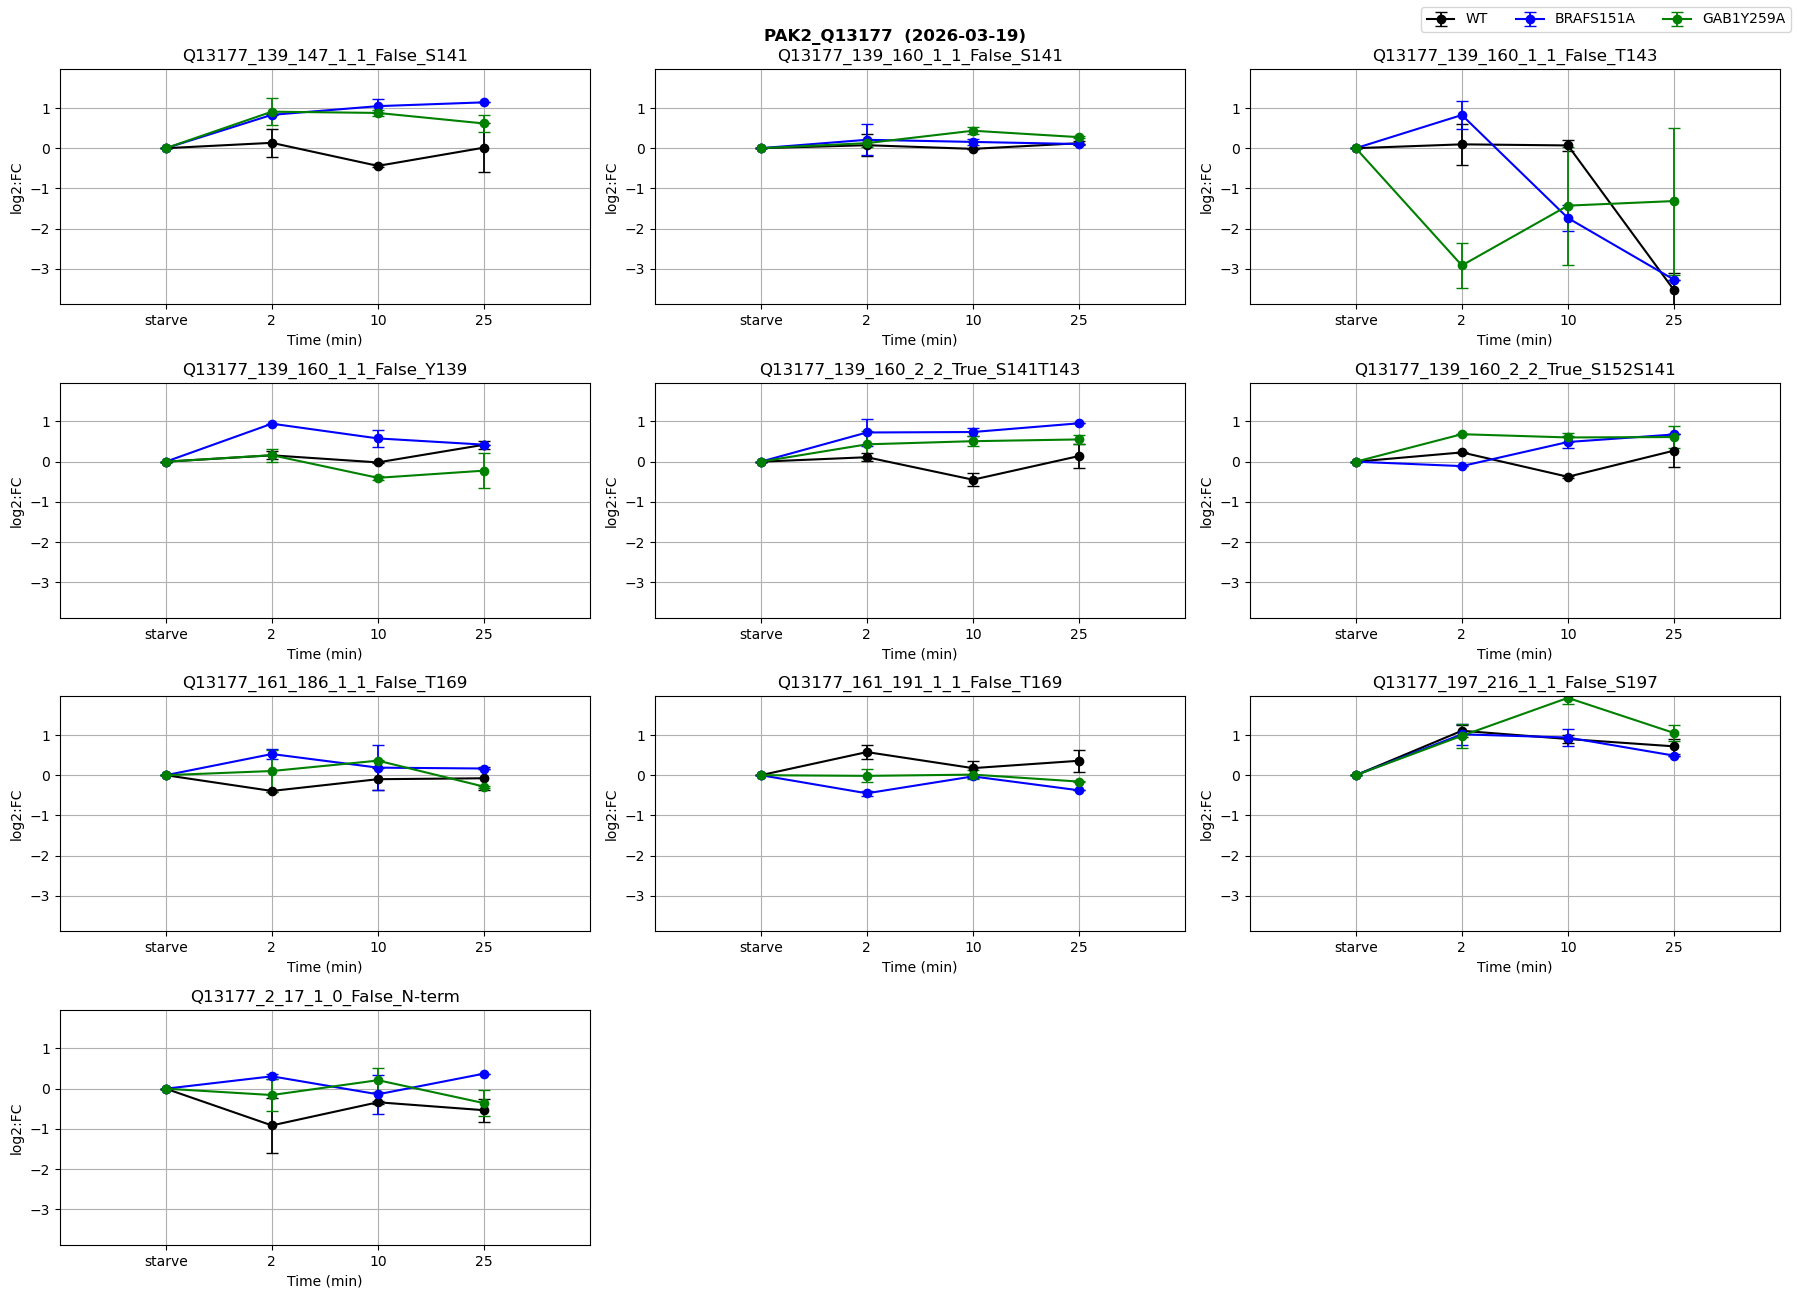

In [63]:
 plot_mutants_protein_phosphosites(df = df_combined,
                                   proteins=["PAK2"],
                                   data_type= "log2:FC",
                                   saving_path = "",
                                   legend_plot=["WT", "BRAFS151A", "GAB1Y259A"],
                                   cell_lines = ["WT", "BRAFS151A", "GAB1Y259A"],
                                   conditions = ["_EGF_"],
                                   color_palette = {"WT" : "black",
                                                 "BRAFS151A" : "blue",
                                                 "GAB1Y259A" : "green"},
                                   fit_y_lims= False
                     )

In [24]:
cell_lines = ["WT", "BRAFS151A", "GAB1Y259A"]
conditions = ["_EGF_"]
data_type = "log2:FC"
def plot_data( ax,
              row_df,
              # replicates = False,
              data_type = "log2:FC",
              colors = {"WT" : "black",
                        "BRAFS151A" : "blue",
                        "GAB1Y259A" : "green"},
              legend = [],
              # exclude_rep = list,
              # plot_individually = False,
              cell_lines = [],
              conditions = [],):

    column_names = row_df.index.tolist()
    # column_names = row_df.columns
    # print(column_names)

    # data_type = "raw
    columns_dir = {cell: {condition: {} for condition in conditions} for cell in cell_lines}

    sub_dtp = data_type.split(":")

    for cell in cell_lines:
        for condition in conditions:
            columns_dir[cell][condition]["plotting"] = [element for element in column_names if element.startswith(cell) and
                                                        condition in element and
                                                        sub_dtp[0] in element and
                                                        sub_dtp[1] in element]
            columns_dir[cell][condition]["sd"] = [element for element in column_names if
                                                  element.startswith(cell) and
                                                  condition in element and
                                                  sub_dtp[0] in element and
                                                  "sd" in element]
    print(columns_dir)

    x_axis_previous = [element for element in column_names if f"{cell}_{data_type}{condition}" in element] # this could be any set of columns that have the time points
    x_axis = [s.split("_")[3] for s in x_axis_previous]

    if data_type in ["raw", "log2", "log2_FC", "FC_scaled"]:
        site = row_df["site"]
        prot_name = row_df["protein_name"]
        protein_ID = row_df["protein_Id"]

        for condition in conditions:
            for cell in cell_lines:
                ax.errorbar(x=x_axis, y=row_df[columns_dir[cell][condition]["plotting"]].values, yerr= row_df[columns_dir[cell][condition]["sd"]].values, marker='o',color=[cell], label=cell, capsize=4, elinewidth=1.3, alpha=1)

                ax.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
                ax.set_xlabel("Time (min)")
                ax.set_ylabel(f"{data_type}")
                ax.grid()
                ax.set_title(f"{site}")
        return ax
    else:
        print(f"Your data type {data_type} is not supported. Try one of these: 'raw', 'log2', 'log2_FC', 'FC_scaled' ")

In [240]:
# plot_data(
#     row_df = df_combined,
#     data_type = "log2_FC",
#     cell_lines = cell_lines,
#     conditions = conditions,)

In [239]:
# cell_lines = ["WT", "BRAFS151A", "GAB1Y259A"]
# conditions = ["_EGF_"]
# data_type = "log2_FC"
# def plot_data( ax,
#               row_df,
#               # replicates = False,
#               data_type = "",
#               colors = {"WT" : "black",
#                         "BRAFS151A" : "blue",
#                         "GAB1Y259A" : "green"},
#               legend = [],
#               # exclude_rep = list,
#               # plot_individually = False,
#               cell_lines = [],
#               conditions = [],):
#
#     column_names = row_df.index.tolist()
#     # column_names = row_df.columns
#     # print(column_names)
#
#     # data_type = "raw
#     columns_dir = {cell: {condition: {} for condition in conditions} for cell in cell_lines}
#
#
#
#     for cell in cell_lines:
#         for condition in conditions:
#
#             if data_type == "log2_FC":
#                 columns_dir[cell][condition]["mean"] = [element for element in column_names if
#                                           element.startswith(cell) and
#                                           condition in element and
#                                           f"{data_type}" in element]
#                 data_type = "log2"
#                 columns_dir[cell][condition]["sd"] = [element for element in column_names if
#                                           element.startswith(cell) and
#                                           condition in element and
#                                           f"{data_type}_sd" in element]
#                 data_type = "log2_FC"
#             else:
#                 columns_dir[cell][condition]["mean"] = [element for element in column_names if
#                                           element.startswith(cell) and
#                                           condition in element and
#                                           f"{data_type}_mean" in element]
#                 columns_dir[cell][condition]["sd"] = [element for element in column_names if
#                                           element.startswith(cell) and
#                                           condition in element and
#                                           f"{data_type}_sd" in element]
#
#     x_axis_previous = [element for element in column_names if f"{cell}_{data_type}{condition}" in element] # this could be any set of columns that have the time points
#     x_axis = [s.split("_")[-1] for s in x_axis_previous]
#
#     # print(data_type, data_type2)
#     if data_type in ["raw", "log2", "log2_FC", "FC_scaled"]:
#         site = row_df["site"]
#         prot_name = row_df["protein_name"]
#         protein_ID = row_df["protein_Id"]
#
#         for condition in conditions:
#             for cell in cell_lines:
#
#
#                 print(row_df[columns_dir[cell][condition]["mean"]].values, type(row_df[columns_dir[cell][condition]["mean"]].values))
#                 print(cell, type(colors[cell]))
#                 print(cell, type(cell))
#                 ax.errorbar(x=x_axis, y=row_df[columns_dir[cell][condition]["mean"]].values, yerr= row_df[columns_dir[cell][condition]["sd"]].values, marker='o',color=colors[cell], label=cell, capsize=4, elinewidth=1.3, alpha=1)
#
#                 ax.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
#                 ax.set_xlabel("Time (min)")
#                 ax.set_ylabel(f"{data_type}")
#                 ax.grid()
#                 ax.set_title(f"{site}")
#         return ax
#     else:
#         print(f"Your data type {data_type} is not supported. Try one of these: 'raw', 'log2', 'log2_FC', 'FC_scaled' ")

In [241]:
# def plot_mutants_protein_phosphosites(df,
#                               data_type = str,
#                               proteins=list,
#                               replicates = False,
#                               exclude_rep = list,
#                               legend_plot = list,
#                               color_palette = {"WT" : "black",
#                                                  "BRAFS151A" : "blue",
#                                                  "GAB1Y259A" : "green"}, #['r', 'b', 'fuchsia'],
#                               saving_path=str,
#                               saving_info="",
#                               title_info = "",
#                               plot_individually=False,
#                               fit_y_lims=False,
#                               plot_close=False,
#                               save_pdf=False,
#                               save_png=False):
#     '''Plot to PDF ALL phosphosites of a list of proteins. You can decide to plot the phosphosties of the protein
#     together in one plot or to plot them separatly.'''
#
#     # Check if the df is a pandas dataframe already or the path to it
#     if type(df) == pd.DataFrame:
#         pass
#     else:
#         df = pd.read_excel(df)
#
#     # If the file generated is not going to be saved don't create the saving folder
#     if save_pdf == False and save_png == False:
#         pass
#     else:  # If the files are going to be saved, check if the path exist, if not, create it
#         if not os.path.exists(saving_path):
#             print("Creating saving folder")
#             os.makedirs(saving_path)
#
#     for protein in proteins:
#         # Create sub-dataframe with only the protein we are interested in. If the protein doesn't exist in the dataframe skip code
#         if protein in df['protein_name'].to_list():
#             sub_df = df.loc[df['protein_name'] == protein].copy()
#             print(f"Ploting sites of protein {protein}")
#         elif protein in df['protein_Id'].to_list():
#             sub_df = df.loc[df['protein_Id'] == protein].copy()
#             print(f"Ploting sites of protein {protein}")
#         else:
#             print(f"The protein {protein} is not present in the dataset")
#             continue
#
#         # Extract the protein name and protein uniprot code for the folder
#         saving_folder = f"{list(sub_df.protein_name)[0]}_{list(sub_df.protein_Id)[0]}"
#
#         # Check if a folder for the desired protein exists. If no, create one
#         if save_pdf == False and save_png == False:
#             pass
#         else:
#             if saving_folder in os.listdir(saving_path):
#                 pass
#             else:
#                 new_path = f"{saving_path}/{saving_folder}"
#                 print(f"Createating saving folder for {saving_folder}")
#                 os.makedirs(new_path)
#
#         # Sort the pepetides of the dataframe for better interpretation of the figure generated
#         sub_df.sort_values(by=['site'], inplace=True)
#
#         # Determine the dimentional space for the subplot
#         number_phos = len(sub_df)
#         sqrt_n_p = int(np.ceil(np.sqrt(number_phos)))  # Plotting time points in a matrix
#         if sqrt_n_p <= 2:  # 1 plot doesn't work, 2 plots leave empty row below
#             empty_plots = 0
#         else:
#             empty_plots = (sqrt_n_p * sqrt_n_p) - number_phos
#         # Avoid getting rows with empty plots
#         if empty_plots >= sqrt_n_p:
#             sqrt_n_p_X = sqrt_n_p - 1
#         else:
#             sqrt_n_p_X = sqrt_n_p
#
#         # Columns to determine the "y" axis limit values
#         column_names = df.columns.tolist()
#         # column_selection = [element for element in column_names if data_type in element]
#         if data_type == "raw":
#             data_type = "raw_mean"
#             column_selection = [element for element in column_names if data_type in element]
#             data_type = "raw"
#         elif data_type == "log2":
#             data_type = "log2_mean"
#             column_selection = [element for element in column_names if data_type in element]
#             data_type = "log2"
#         else:
#             column_selection = [element for element in column_names if data_type in element and "clusters" not in element]
#         print(column_selection)
#
#         if plot_individually == True:
#             for index, row in sub_df.iterrows():
#
#                 protein_name = row["protein_name"]
#                 site = row["site"]
#                 # Y axis limit
#                 if fit_y_lims == True:
#                     y_fixed = "y_axis_fixed"
#                 elif type(fit_y_lims) == list:
#                     y_lim_min = fit_y_lims[0]
#                     y_lim_max = fit_y_lims[1]
#                     y_fixed = f"_y_axis_fixed_{y_lim_min}_{y_lim_max}"
#                 elif fit_y_lims == False:
#                     sub_values_df = sub_df.loc[:,column_selection]
#                     y_lim_max = (sub_values_df.max().max()) * 1.05
#                     y_lim_min = (sub_values_df.min().min()) * 0.95
#                     if y_lim_min < 0:
#                         y_lim_min = (sub_values_df.min().min()) + (sub_values_df.min().min())* 0.1
#
#                 fig, axes = plt.subplots()
#                 plot_data(ax = axes, row_df = row, data_type= data_type, colors = color_palette, legend = legend_plot, cell_lines= ["WT", "BRAFS151A", "GAB1Y259A"], conditions= ["_EGF_"])
#                 # Apply the y limit axis
#                 if fit_y_lims == True:
#                     if data_type == "raw" or data_type == "log2_FC":
#                         if min(row[column_selection]) < 0 :
#                             y_lim_min = min(row[column_selection]) + min(row[column_selection])*0.1
#                             axes.set_ylim(y_lim_min, max(row[column_selection])*1.1)
#                         else:
#                             axes.set_ylim(min(row[column_selection])*0.9, max(row[column_selection])*1.1)
#                     else:
#                         axes.set_ylim(min(row[column_selection])*0.97, max(row[column_selection])*1.02)
#                 else:
#                     axes.set_ylim(y_lim_min, y_lim_max)
#                 axes.set_xlim(-1, 4)
#
#                 if save_pdf == True:
#                     plt.savefig(f"{saving_path}/{saving_folder}/{protein_name}_{site}_{saving_info}.pdf")
#                     print(f"{protein_name}_{site}_{saving_info}.pdf Plot saved as PDF")
#                 if save_png == True:
#                     plt.savefig(f"{saving_path}/{saving_folder}/{protein_name}_{site}_{saving_info}.png")
#                     print(f"{protein_name}_{site}_{saving_info}.png Plot saved as PNG")
#                 if save_pdf == False and save_png == False:
#                     print(f"{protein_name}_{site}_{saving_info} Plot not saved")
#
#         else:
#             k = 0
#             fig, axes = plt.subplots(sqrt_n_p, sqrt_n_p_X , figsize=(18, 13))  #
#             fig.tight_layout(w_pad=1.75, h_pad=3)
#             plt.subplots_adjust(top=0.94)
#
#             # Force axes into a 2D array
#             if len(sub_df) == 1:
#                 axes = np.array([[axes]])  # Wrap single Axes in a 2D array
#             elif sqrt_n_p == 1 or sqrt_n_p_X == 1:
#                 axes = np.atleast_2d(axes)
#
#             # Y axis limit
#             if fit_y_lims == True:
#                 y_fixed = "y_axis_fixed"
#             elif type(fit_y_lims) == list:
#                 y_lim_min = fit_y_lims[0]
#                 y_lim_max = fit_y_lims[1]
#                 y_fixed = f"_y_axis_fixed_{y_lim_min}_{y_lim_max}"
#             elif fit_y_lims == False:
#                 sub_values_df = sub_df.loc[:,column_selection]
#                 y_lim_max = (sub_values_df.max().max()) * 1.02
#                 y_lim_min = (sub_values_df.min().min()) * 0.97
#                 if y_lim_min < 0:
#                     y_lim_min = (sub_values_df.min().min()) + (sub_values_df.min().min())* 0.1
#
#             for i in range(sqrt_n_p):  # y
#                 for j in range(sqrt_n_p_X):  # X
#                     if k >= number_phos:  # Stop plotting, all phosphorylation sites have been plotted
#                         fig.delaxes(axes[i, j])
#
#                     else:
#                         row = sub_df.iloc[k,:]
#                         # print(data_type)
#
#                         plot_data(ax = axes[i,j], row_df = row,  data_type= data_type, colors = color_palette, legend = legend_plot, cell_lines= ["WT", "BRAFS151A", "GAB1Y259A"], conditions= ["_EGF_"]) # data_type= data_type,
#
#                         if fit_y_lims == True:
#                             if data_type == "raw" or data_type == "log2_FC":
#                                 if min(row[column_selection]) < 0 :
#                                     y_lim_min = min(row[column_selection]) + min(row[column_selection])*0.1
#                                     axes[i,j].set_ylim(y_lim_min, max(row[column_selection])*1.1)
#                                 else:
#                                     axes[i,j].set_ylim(min(row[column_selection])*0.9, max(row[column_selection])*1.1)
#                             else:
#                                 axes[i,j].set_ylim(min(row[column_selection])*0.97, max(row[column_selection])*1.02)
#                         else:
#                             axes[i, j].set_ylim(y_lim_min, y_lim_max)
#
#                         axes[i, j].set_xlim(-1, 4)
#                         # fig.tight_layout()
#                         k = k + 1
#
#             fig.legend(labels=legend_plot, loc="upper right", ncol=3)
#             fig.suptitle(f"{saving_folder} {title_info} ({date.today()})", weight='bold')
#             fig.tight_layout()
#
#             if save_pdf == True:
#                 plt.savefig(f"{saving_path}/{saving_folder}/{saving_folder}_{data_type}_{saving_info}.pdf")
#                 print(f"{saving_folder}_{data_type}_{saving_info}.pdf Plot saved as PDF")
#             if save_png == True:
#                 plt.savefig(f"{saving_path}/{saving_folder}/{saving_folder}_{data_type}_{saving_info}.png")
#                 print(f"{saving_folder}_{data_type}_{saving_info}.png Plot saved as PNG")
#             if save_pdf == False and save_png == False:
#                 print(f"{saving_folder}_{data_type}_{saving_info} Plot not saved")
#     if plot_close == True:
#         plt.close(fig)

In [242]:
# plot_mutants_protein_phosphosites(df = df_combined,
#                                   proteins=["BRAF", "EGFR", "MAPK3"],
#                                   data_type= "log2_FC",
#                                   saving_path = "",
#                                   legend_plot=["WT", "BRAFS151A", "GAB1Y259A"]
#                      )

# improving the plotting

In [20]:
# plot_data(
#     row_df = df_combined,
#     data_type = "log2:FC",
#     cell_lines = cell_lines,
#     conditions = conditions,)

In [27]:
def plot_mutants_protein_phosphosites(df,
                              data_type = str,
                              proteins=list,
                              replicates = False,
                              exclude_rep = list,
                              legend_plot = list,
                              color_palette = {"WT" : "black",
                                                 "BRAFS151A" : "blue",
                                                 "GAB1Y259A" : "green"}, #['r', 'b', 'fuchsia'],
                              saving_path=str,
                              cell_lines = [],
                              conditions = [],
                              saving_info="",
                              title_info = "",
                              plot_individually=False,
                              fit_y_lims=False,
                              plot_close=False,
                              save_pdf=False,
                              save_png=False):
    '''Plot to PDF ALL phosphosites of a list of proteins. You can decide to plot the phosphosties of the protein
    together in one plot or to plot them separatly.'''

    # Check if the df is a pandas dataframe already or the path to it
    if type(df) == pd.DataFrame:
        pass
    else:
        if ".xlsx" in df:
            df = pd.read_excel(df)
        elif ".tsv" in df:
            df = pd.read_csv(df, sep="\t")

    for protein in proteins:
        # Create sub-dataframe with only the protein we are interested in. If the protein doesn't exist in the dataframe skip code
        if protein in df['protein_name'].to_list():
            sub_df = df.loc[df['protein_name'] == protein].copy()
            print(f"Ploting sites of protein {protein}")
        elif protein in df['protein_Id'].to_list():
            sub_df = df.loc[df['protein_Id'] == protein].copy()
            print(f"Ploting sites of protein {protein}")
        else:
            print(f"The protein {protein} is not present in the dataset")
            continue

        # Extract the protein name and protein uniprot code for the folder
        saving_folder = f"{list(sub_df.protein_name)[0]}_{list(sub_df.protein_Id)[0]}"

        # Check if a folder for the desired protein exists. If no, create one
        if save_pdf == False and save_png == False:
            pass
        else:
            if saving_folder in os.listdir(saving_path):
                pass
            else:
                new_path = f"{saving_path}/{saving_folder}"
                print(f"Createating saving folder for {saving_folder}")
                os.makedirs(new_path)

        # Sort the pepetides of the dataframe for better interpretation of the figure generated
        sub_df.sort_values(by=['site'], inplace=True)

        # Determine the dimentional space for the subplot
        number_phos = len(sub_df)
        sqrt_n_p = int(np.ceil(np.sqrt(number_phos)))  # Plotting time points in a matrix
        if sqrt_n_p <= 2:  # 1 plot doesn't work, 2 plots leave empty row below
            empty_plots = 0
        else:
            empty_plots = (sqrt_n_p * sqrt_n_p) - number_phos
        # Avoid getting rows with empty plots
        if empty_plots >= sqrt_n_p:
            sqrt_n_p_X = sqrt_n_p - 1
        else:
            sqrt_n_p_X = sqrt_n_p

        # Columns to determine the "y" axis limit values
        column_names = df.columns.tolist()
        sub_dtp = data_type.split(":")
        column_selection = [element for element in column_names if data_type in element and "clusters" not in element]
        # print(column_selection)

        # Plotting
        k = 0
        fig, axes = plt.subplots(sqrt_n_p, sqrt_n_p_X , figsize=(18, 13))  #
        fig.tight_layout(w_pad=1.75, h_pad=3)
        plt.subplots_adjust(top=0.94)

        # Force axes into a 2D array
        if len(sub_df) == 1:
            axes = np.array([[axes]])  # Wrap single Axes in a 2D array
        elif sqrt_n_p == 1 or sqrt_n_p_X == 1:
            axes = np.atleast_2d(axes)

        # Y axis limit
        if fit_y_lims == True:
            y_limt_info = "y_axis_fixed"
        elif type(fit_y_lims) == list:
            y_lim_min = fit_y_lims[0]
            y_lim_max = fit_y_lims[1]
            y_limt_info = f"_y_axis_fixed_{y_lim_min}_{y_lim_max}"
        elif fit_y_lims == False:
            sub_values_df = sub_df.loc[:,column_selection]
            y_lim_max = (sub_values_df.max().max()) * 1.02
            y_lim_min = (sub_values_df.min().min()) * 0.97
            if y_lim_min < 0:
                y_lim_min = (sub_values_df.min().min()) + (sub_values_df.min().min())* 0.1

        for i in range(sqrt_n_p):  # y
            for j in range(sqrt_n_p_X):  # X
                if k >= number_phos:  # Stop plotting, all phosphorylation sites have been plotted
                    fig.delaxes(axes[i, j])

                else:
                    row = sub_df.iloc[k,:]
                    # print(data_type)

                    plot_data(ax = axes[i,j], row_df = row,  data_type= data_type, colors = color_palette, legend = legend_plot, cell_lines= cell_lines, conditions= conditions) # data_type= data_type,

                    if fit_y_lims == True:
                        if data_type == "raw" or data_type == "log2_FC":
                            if min(row[column_selection]) < 0 :
                                y_lim_min = min(row[column_selection]) + min(row[column_selection])*0.1
                                axes[i,j].set_ylim(y_lim_min, max(row[column_selection])*1.1)
                            else:
                                axes[i,j].set_ylim(min(row[column_selection])*0.9, max(row[column_selection])*1.1)
                        else:
                            axes[i,j].set_ylim(min(row[column_selection])*0.97, max(row[column_selection])*1.02)
                    else:
                        axes[i, j].set_ylim(y_lim_min, y_lim_max)

                    axes[i, j].set_xlim(-1, 4)
                    # fig.tight_layout()
                    k = k + 1

        fig.legend(labels=legend_plot, loc="upper right", ncol=3)
        fig.suptitle(f"{saving_folder} {title_info} ({date.today()})", weight='bold')
        fig.tight_layout()

    #     if save_pdf == True:
    #         plt.savefig(f"{saving_path}/{saving_folder}/{saving_folder}_{data_type}_{saving_info}.pdf")
    #         print(f"{saving_folder}_{data_type}_{saving_info}.pdf Plot saved as PDF")
    #     if save_png == True:
    #         plt.savefig(f"{saving_path}/{saving_folder}/{saving_folder}_{data_type}_{saving_info}.png")
    #         print(f"{saving_folder}_{data_type}_{saving_info}.png Plot saved as PNG")
    #     if save_pdf == False and save_png == False:
    #         print(f"{saving_folder}_{data_type}_{saving_info} Plot not saved")
    # if plot_close == True:
    #     plt.close(fig)